## Lecture 10 Machine Learning II: Text Analysis with Classification and Large Language Models

### 1. Machine Learning and Text Classification

**Review: What is Machine Learning?**

Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit instructions.

Advances in the field of deep learning have allowed neural networks to surpass many previous approaches in performance.

**Review: Classification Model**

Definition: A model whose prediction is a class. For example, the following are all classification models:
 - A model that predicts an input sentence's language (French? Spanish? Italian?).
 - A model that predicts tree species (Maple? Oak? Baobab?).
 - A model that predicts the positive or negative class for a particular medical condition.
 - A model that predicts if an official can get promotion
 - A model that predicts if a war will happen
 - A model that predicts which candidate can win the election

In contrast, regression models predict numbers rather than classes.

**Text Classification Model**

Definition: A ML model whose input (X) is text and predicted target (y) is a class. For example, the following are all classification models:

A model predicting
- if a social media post contains hate speech
- if a official document discusses political violence
- if a question in a preference conference contains positive/ negative/ neutral sentiment
- if a question to ChatGPT is inappropriate, for which ChatGPT should refuse to answer

**Speciality of Text Classification**

In terms of 1) Define X and Y and 2) Interpret model. We will talk about them in details.

### 2. Application of Classification to Text Data

**What Have We Done with These Data?**

- Extracting Textual Features: Linguistic features (Tokenization, Lemmatization, Stopword removal), and Named Entities

- Topic Modeling
  We used a bag-of-word approach to extract textual features and conducted some macro-level (corpus-level) analysis. We have not done any micro-level analysis

**Task: Develop a ML classifier to identify "aggressive" questions in the MoFA dataset.**

Steps:

- Manually label a small portion of the MoFA Q&A
- Train and evaluate a ML classifier
- Apply the ML classifier to Q&A that are not manually labeled

In [ ]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
PATH_PROJECT = "/content/drive/MyDrive/POLI3148_2024Fall/Exercise/Week12/demo_ml_2_TextClassification"

In [ ]:
os.chdir(PATH_PROJECT)

**Data Input**

In [ ]:
df = pd.read_excel("data_raw/CMFA_PressCon_v4.xlsx")

In [ ]:
df

,id_orig,id_split,id,link,spokesperson,day,month,year,date,question,...,q_loc,q_per,q_org,q_misc,a_loc,a_per,a_org,a_misc,a_sentiment,q_sentiment
0,1,1,1,http://web.archive.org/web/20030907084940/http...,Zhang Qiyue,15,October,2002,2002-10-15 00:00:00,How many Hong Kong and Taiwan people were inju...,...,Taiwan; Mainland; Indonesia; Hong Kong; Bali I...,-,-,Chinese,Taiwan; Mainland; Macao; Indonesia; Hong Kong;...,-,Government,Indonesian; Chinese,2.354945,0.939969
1,2,2,2,http://web.archive.org/web/20030907084940/http...,Zhang Qiyue,15,October,2002,2002-10-15 00:00:00,"Today, five Japanese who were kidnapped by the...",...,North Korea; China,-,-,-,Japan; DPRK; China,-,-,Japan-DPRK,5.112201,2.474082
2,3,3,3,http://web.archive.org/web/20030907084940/http...,Zhang Qiyue,15,October,2002,2002-10-15 00:00:00,Recently Nepal formed an interim government. H...,...,Nepal,-,-,-,Nepal; China,-,Nepali Interim Government,Nepali; Five Principles of Peaceful Coexistenc...,4.926227,3.039821
3,4,4,4,http://web.archive.org/web/20030907084940/http...,Zhang Qiyue,15,October,2002,2002-10-15 00:00:00,Pakistan held the general election on 10 Octob...,...,-,-,-,-,Pakistan; China,-,-,China-Pakistan,5.282908,2.699500
4,5,5,5,http://web.archive.org/web/20030907084940/http...,Zhang Qiyue,15,October,2002,2002-10-15 00:00:00,Is China concerned about the rise of the funda...,...,US; Pakistan; China,-,-,-,Pakistan,-,-,Pakistani,5.174895,2.123604
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30959,29093,29093,30960,https://www.fmprc.gov.cn/eng/xwfw_665399/s2510...,Mao Ning,29,December,2023,2023-12-29 00:00:00,"In an interview with RIA news agency, Russian ...",...,Russia; Global South; China,Volodymyr Zelenskyy; Sergey Lavrov,RIA,Western; Ukrainian; Russian,Ukraine; China,-,-,Chinese,4.447462,2.524199
30960,29094,29094,30961,https://www.fmprc.gov.cn/eng/xwfw_665399/s2510...,Mao Ning,29,December,2023,2023-12-29 00:00:00,A spokesperson of one of the local armed group...,...,Myanmar; China,-,NHK,Chinese,Myanmar; China-Myanmar; China,-,-,-,4.202277,1.660094
30961,29095,29095,30962,https://www.fmprc.gov.cn/eng/xwfw_665399/s2510...,Mao Ning,29,December,2023,2023-12-29 00:00:00,It’s reported that the spokesperson of the Arm...,...,Ren’ai Jiao; Philippines,Aguilar,Armed Forces of the Philippines,Philippino,South China Sea; Ren’ai Jiao; Philippines; Nan...,Ren’ai Jiao,Nansha Qundao; Crown Hotel; Armed Forces of th...,UN Charter; Ren’ai Jiao; DOC; Declaration on t...,1.731000,2.697861
30962,29096,29096,30963,https://www.fmprc.gov.cn/eng/xwfw_665399/s2510...,Mao Ning,29,December,2023,2023-12-29 00:00:00,It’s been learned that firing broke out in fro...,...,Myanmar; Laukkaing Township; Laukkaing; Dong C...,-,Crown Hotel,Chinese,Myanmar; Kokang; China,-,Foreign Ministry,Chinese,0.507228,1.371034


The researcher who compiled the data has provided a column of sentiment. We are making use of that as our label.

<Axes: ylabel='Frequency'>

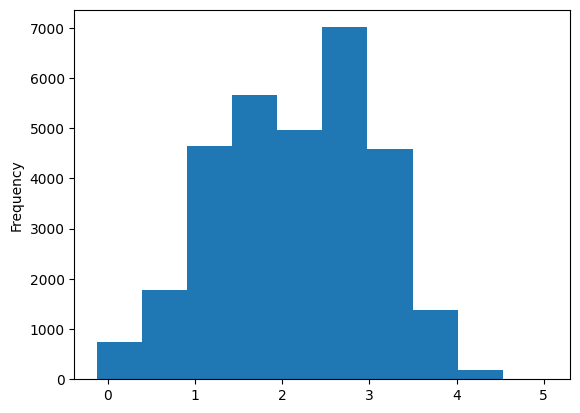

In [ ]:
df.q_sentiment.plot.hist()

In [ ]:
df.q_sentiment.describe()

,q_sentiment
count,30964.000000
mean,2.165400
std,0.881944
min,-0.124559
25%,1.473351
50%,2.217957
75%,2.877475
max,5.047039


Define the bottom 25% as "aggressive questions". Others are regarded non-aggressive. This provides the binary outcome for the machine learning model.

In [ ]:
df['q_aggressive'] = (df.q_sentiment <= 1.473351)

In [ ]:
# df.loc[:, 'q_aggressive'] = df.loc[:, 'q_aggressive'].astype(int)

<ipython-input-36-6645e23cbfc7>:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1 0 0 ... 0 1 1]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[:, 'q_aggressive'] = df.loc[:, 'q_aggressive'].astype(int)


In [ ]:
df.q_aggressive.value_counts()

,count
q_aggressive,
False,23223
True,7741


We use the linguistic features as predictors. We first import the data.

In [ ]:
text_ling = pd.read_csv("data_processed/text_ling.csv")

In [ ]:
text_ling

,token,lower,lemma,pos,stopword,id
0,opening_remark,opening_remark,opening_remark,X,False,28448
1,The,the,the,DET,True,28449
2,2023,2023,2023,NUM,False,28449
3,New,new,New,PROPN,False,28449
4,Year,year,Year,PROPN,False,28449
...,...,...,...,...,...,...
124522,do,do,do,VERB,True,30964
124523,with,with,with,ADP,True,30964
124524,those,those,those,DET,True,30964
124525,people,people,people,NOUN,False,30964


As normal, we remove number, stopwords, punctuations, and preserve lemmas.

In [ ]:
text_ling_s = text_ling.loc[(text_ling.stopword == False) &
  (~text_ling.pos.isin(['X', 'PUNCT', 'NUM']) ), ["id", "lemma"]]

In [ ]:
text_ling_s

,id,lemma
3,28449,New
4,28449,Year
5,28449,Address
7,28449,President
8,28449,Xi
...,...,...
124515,30964,telecom
124516,30964,fraud
124517,30964,suspect
124521,30964,China


**Constructing X**

For the text, we transform them into a stopword-free collection of lemmas. The ids are preserved as well. Because the sentiment information we had was on the document level, each of which has an id for us to associate the lemmas with the document where they were in.

In [ ]:
df_clean_X = text_ling_s.groupby("id")['lemma'].apply(list).reset_index()
df_clean_X

,id,lemma
0,28449,"[New, Year, Address, President, Xi, Jinping, r..."
1,28450,"[recently, China, announce, decision, manage, ..."
2,28451,"[pay, close, attention, China, communication, ..."
3,28452,"[russian, President, Vladimir, Putin, invite, ..."
4,28453,"[accord, report, newly, inaugurate, brazilian,..."
...,...,...
2435,30960,"[interview, RIA, news, agency, russian, Foreig..."
2436,30961,"[spokesperson, local, armed, group, Myanmar, t..."
2437,30962,"[report, spokesperson, Armed, Forces, Philippi..."
2438,30963,"[learn, firing, break, Crown, Hotel, Dong, Che..."


In [ ]:
df_clean_X.loc[0, 'lemma']

['New',
 'Year',
 'Address',
 'President',
 'Xi',
 'Jinping',
 'receive',
 'international',
 'community',
 'People',
 'country',
 'say',
 'President',
 'word',
 'convey',
 'hope',
 'confidence',
 'world',
 'believe',
 'China',
 'wisdom',
 'solution',
 'important',
 'contribution',
 'cause',
 'peace',
 'development',
 'humanity',
 'effort',
 'China',
 'diplomacy',
 'achieve',
 'new',
 'year']

**Constructing Y**

Create a “q_aggressive” column using the existing “q_sentiment” column.

This is the outcome variable dataset, containing the document id and whether or not it was agreessive, which we manually labeled.

Normally, y is obtained through manual labeling We take advantage of the dataset, which obtain the sentiment of questions using other machine learning methods. For this task, we defined it as questions whose sentiment scores are at the bottom 25 percentile.

In [ ]:
df_clean_y = df.loc[:, ['id', 'q_aggressive']]
df_clean_y

,id,q_aggressive
0,1,True
1,2,False
2,3,False
3,4,False
4,5,False
...,...,...
30959,30960,False
30960,30961,False
30961,30962,False
30962,30963,True


We merge both datasets, using id as the index for this merging.

In [ ]:
df_clean_Xy = pd.merge(df_clean_X, df_clean_y, on = "id")
df_clean_Xy

,id,lemma,q_aggressive
0,28449,"[New, Year, Address, President, Xi, Jinping, r...",False
1,28450,"[recently, China, announce, decision, manage, ...",False
2,28451,"[pay, close, attention, China, communication, ...",False
3,28452,"[russian, President, Vladimir, Putin, invite, ...",False
4,28453,"[accord, report, newly, inaugurate, brazilian,...",False
...,...,...,...
2435,30960,"[interview, RIA, news, agency, russian, Foreig...",False
2436,30961,"[spokesperson, local, armed, group, Myanmar, t...",False
2437,30962,"[report, spokesperson, Armed, Forces, Philippi...",False
2438,30963,"[learn, firing, break, Crown, Hotel, Dong, Che...",True


Create a document-term matrix using CountVectorizer.

In this matrix, each document is a row, and each word is a column. It is assumed that for documents that share more columns, they will be semantically closer to each other. If you don't quite remember the concept, you can go to lecture 8 slides.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

def dummy(X):
  return X

vectorizer = CountVectorizer(tokenizer = dummy, preprocessor = dummy, min_df = 10) # Keep words that appear in at least in 10 documents. We do not want ultra-low frequency words to influence the model.
X = vectorizer.fit_transform(df_clean_Xy.lemma)

In [ ]:
X

<2440x1011 sparse matrix of type '<class 'numpy.int64'>'
	with 39320 stored elements in Compressed Sparse Row format>

In [ ]:
X[:20, :20].toarray()

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
X_names = vectorizer.get_feature_names_out()
print(f"Vocabulary Size: {len(X_names)}")
print(f"First few words: {X_names[:10]}")

Vocabulary Size: 1011
First few words: ['$' '%' '-' '10th' 'APEC' 'ASEAN' 'Act' 'Advisor' 'Affairs' 'Afghanistan']


In [ ]:
y = df_clean_Xy.q_aggressive.values.astype(int)

In [ ]:
y

array([0, 0, 0, ..., 0, 1, 1])

In [ ]:
X

<2440x1011 sparse matrix of type '<class 'numpy.int64'>'
	with 39320 stored elements in Compressed Sparse Row format>

In [ ]:
y

array([0, 0, 0, ..., 0, 1, 1])

At the end of this procedure, you have a dataset that already contains the X and the Y. The X is the words in the documents, and the Y is whether or not they are agreessive. We are using the same model, i.e., logistic regression to model what words contribute to the agreessiveness. It follows the same logic of our model that predicts whether or not an official gets promoted using their age, gender, experiences, etc.

**Train-Test Split**

As always, we split the data into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 123)

**Fit ML Models**

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model_lr = LogisticRegression()

In [ ]:
model_lr

LogisticRegression()

In [ ]:
model_lr.fit(X_train, y_train)

LogisticRegression()

**Interpret Model: Coefficients**

In [ ]:
model_interpretation = pd.DataFrame({'Predictor': X_names, 'Coefficient': model_lr.coef_[0]})
model_interpretation

,Predictor,Coefficient
0,$,0.425465
1,%,-0.278685
2,-,-0.645234
3,10th,-0.179937
4,APEC,-0.585962
...,...,...
1006,write,-0.154084
1007,year,0.220743
1008,yesterday,-0.549780
1009,zone,0.829536


In [ ]:
model_interpretation = model_interpretation.sort_values('Coefficient', ascending = False)
model_interpretation

,Predictor,Coefficient
280,accuse,1.706687
332,attack,1.587194
803,reason,1.413149
550,force,1.379081
542,financial,1.280943
...,...,...
596,important,-1.290974
679,meet,-1.306277
876,share,-1.309643
521,exchange,-1.426849


Text(0.5, 1.0, 'Coefficients of Logistic Regression')

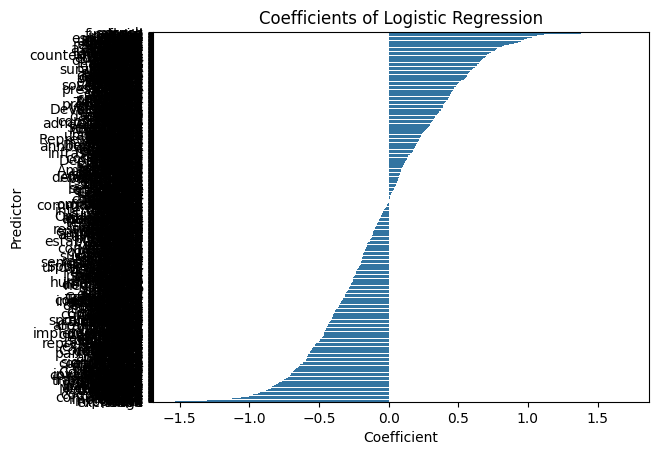

In [ ]:
sns.barplot(y = "Predictor", x = "Coefficient", data = model_interpretation)
plt.title("Coefficients of Logistic Regression")
# So ugly!

Text(0.5, 1.0, 'Top 30 Words Predicting Aggressiveness')

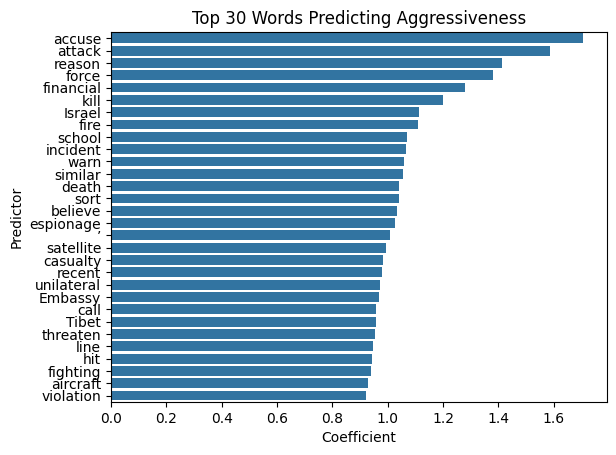

In [ ]:
sns.barplot(y = "Predictor", x = "Coefficient",
            data = model_interpretation.head(30))
plt.title("Top 30 Words Predicting Aggressiveness")

Inversely, we can also see what words predict non-agressiveness. These seems to intuitively make sense.

Text(0.5, 1.0, 'Top 30 Words Predicting Non-Aggressiveness')

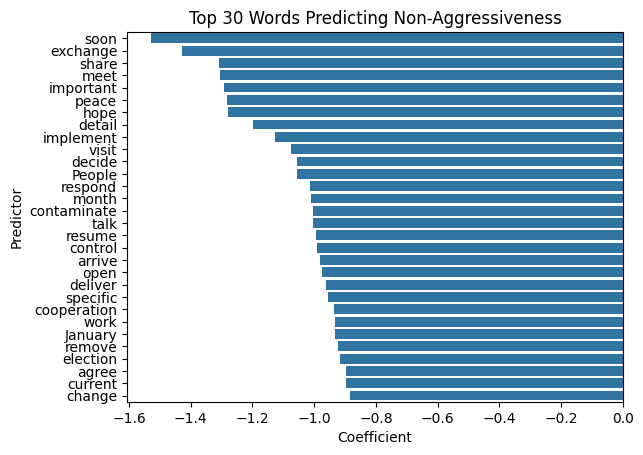

In [ ]:
sns.barplot(y = "Predictor", x = "Coefficient",
            data = model_interpretation.tail(30).sort_values("Coefficient"))
plt.title("Top 30 Words Predicting Non-Aggressiveness")

**Evaluating the model**

In [ ]:
from sklearn import metrics

def evaluate_model(model, X_test, y_test, threshold = 0.5):
  # Get predicted probability for the test set
  y_test_predicted_probability = model.predict_proba(X_test)
  y_test_predicted_probability
  y_test_predicted_probability_1 = y_test_predicted_probability[:, 1]
  y_test_predicted = (y_test_predicted_probability_1 > threshold)

  # Calcualte accuracy
  print(f"Accuracy: {metrics.accuracy_score(y_test, y_test_predicted)}")
  print(f"Precision: {metrics.precision_score(y_test, y_test_predicted)}")
  print(f"Recall: {metrics.recall_score(y_test, y_test_predicted)}")
  print(f"F1 Score: {metrics.f1_score(y_test, y_test_predicted)}")
  print(f"ROC-AUC: {metrics.roc_auc_score(y_test, y_test_predicted_probability_1)}")

  false_positive_rate, true_positive_rate, _ = metrics.roc_curve(y_test, y_test_predicted_probability_1)
  auc = metrics.roc_auc_score(y_test, y_test_predicted_probability_1)
  plt.figure()
  plt.plot(false_positive_rate, true_positive_rate)
  plt.plot([0, 1], [0, 1], '--', color = 'gray')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'ROC Curve (AUC = {round(auc, 2)})')
  plt.show()


Accuracy: 0.8073770491803278
Precision: 0.5757575757575758
Recall: 0.5229357798165137
F1 Score: 0.5480769230769231
ROC-AUC: 0.8234126503836751


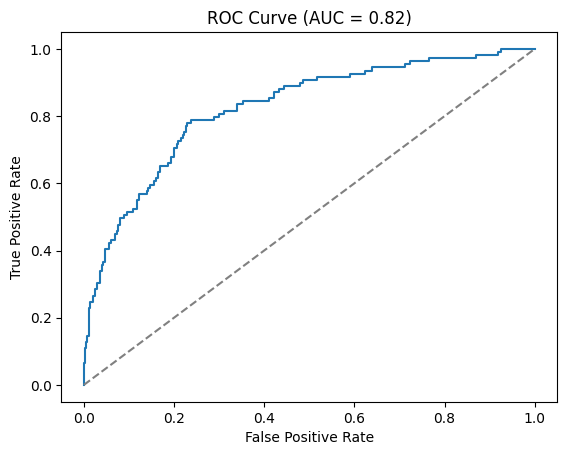

In [ ]:
evaluate_model(model = model_lr, X_test = X_test, y_test = y_test, threshold = 0.5)

**Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators = 100) # 100 trees
model_rf.fit(X_train, y_train)


RandomForestClassifier()

Accuracy: 0.8135245901639344
Precision: 0.625
Recall: 0.41284403669724773
F1 Score: 0.4972375690607735
ROC-AUC: 0.8206530948173609


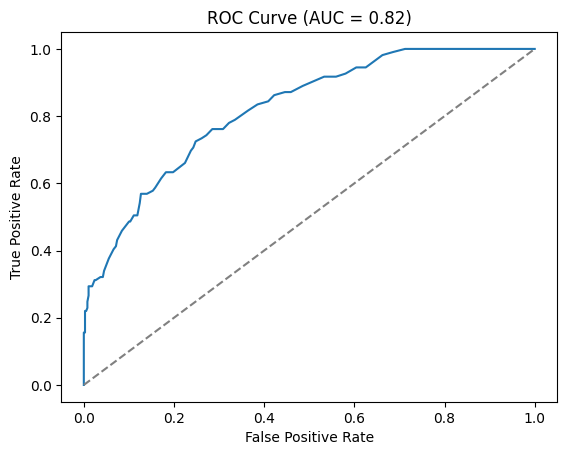

In [ ]:
evaluate_model(model = model_rf, X_test = X_test, y_test = y_test, threshold = 0.5)

In [ ]:
model_interpretation = pd.DataFrame({"Predictor": X_names, "Importance": model_rf.feature_importances_})
model_interpretation = model_interpretation.sort_values("Importance", ascending = False)

model_interpretation

,Predictor,Importance
332,attack,1.704464e-02
986,visit,1.537062e-02
280,accuse,1.354066e-02
876,share,1.268110e-02
630,kill,1.179698e-02
...,...,...
429,counterpart,9.691435e-06
399,common,7.257756e-06
148,Leyen,5.889840e-06
915,strengthen,3.180564e-06


Text(0.5, 1.0, 'Top 30 Most Important Predictors')

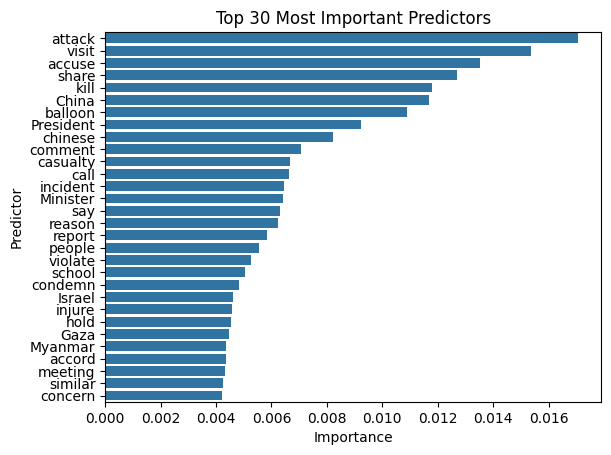

In [ ]:
sns.barplot(y = "Predictor", x = "Importance",
            data = model_interpretation.head(30))
plt.title("Top 30 Most Important Predictors")

### 2. Text Analysis with LLM

We have covered traditional machine learning model that has been there for a long time. So their benefit is that they're reliable. They have a long history, and people know how to interpret them. And that's very important that you are able to actually interpret them in a concise way. For example, coefficient. You can interpret the feature importance. And then that makes these type of machine learning models super useful for social scientists.

But there are a different set of machine learning models, which is the latest deep learning models. They perform better with even more complicated setup. Some may find the previous models unintuitive, then this deep learning would be even less understandable. They are mimicking the human brain organization in that there are neurons of many different layers and parameters. They are also interconnected with each other.

The caveat is that these models are not interpretable. You cannot learn from this model. It only tells you the result of, for example, whether or not this particular official can get promoted or not. It does not tell you have important some traits or properties of that person may contribute to their promotion.

We are using open-source models from HuggingFace. There are two types of models. One is owned by those big tech companies. They built and use their model, but they are not fully transparent about their model. The other type, which we will use, is open-source. Researchers who build them publish papers and open sourced their model on this platform.

Follow the notebook in each step to analyze texts with LLM.

Note:
This notebook is downloaded from: https://github.com/casualcomputer/llm_google_colab/blob/main/setup_llm_on_google_colab_gpu_accelerated.ipynb

Dr. Haohan Chen does the following work:
1. Run the notebook on Google Golab to validate.
2. Added the second section to demonstrate how the model can be applied to political text data.

Note: I recommend that the model be saved locally so that there is no need to re-download the model.

#### Deep Learning for Text Classification

Using Deep Learning Model on Hugging Face

Check out all text classification models: https://huggingface.co/models?pipeline_tag=text-classification&sort=trending

Example we use for demo: https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest

In [ ]:
import pandas as pd
import os

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
PATH_PROJECT = "/content/drive/MyDrive/POLI3148_2024Fall/Exercise/Week12/demo_ml_2_TextClassification"

In [ ]:
os.chdir(PATH_PROJECT)

**Data Input**

In [ ]:
df = pd.read_excel("data_raw/CMFA_PressCon_v4.xlsx")

In [ ]:
df

,id_orig,id_split,id,link,spokesperson,day,month,year,date,question,...,q_loc,q_per,q_org,q_misc,a_loc,a_per,a_org,a_misc,a_sentiment,q_sentiment
0,1,1,1,http://web.archive.org/web/20030907084940/http...,Zhang Qiyue,15,October,2002,2002-10-15 00:00:00,How many Hong Kong and Taiwan people were inju...,...,Taiwan; Mainland; Indonesia; Hong Kong; Bali I...,-,-,Chinese,Taiwan; Mainland; Macao; Indonesia; Hong Kong;...,-,Government,Indonesian; Chinese,2.354945,0.939969
1,2,2,2,http://web.archive.org/web/20030907084940/http...,Zhang Qiyue,15,October,2002,2002-10-15 00:00:00,"Today, five Japanese who were kidnapped by the...",...,North Korea; China,-,-,-,Japan; DPRK; China,-,-,Japan-DPRK,5.112201,2.474082
2,3,3,3,http://web.archive.org/web/20030907084940/http...,Zhang Qiyue,15,October,2002,2002-10-15 00:00:00,Recently Nepal formed an interim government. H...,...,Nepal,-,-,-,Nepal; China,-,Nepali Interim Government,Nepali; Five Principles of Peaceful Coexistenc...,4.926227,3.039821
3,4,4,4,http://web.archive.org/web/20030907084940/http...,Zhang Qiyue,15,October,2002,2002-10-15 00:00:00,Pakistan held the general election on 10 Octob...,...,-,-,-,-,Pakistan; China,-,-,China-Pakistan,5.282908,2.699500
4,5,5,5,http://web.archive.org/web/20030907084940/http...,Zhang Qiyue,15,October,2002,2002-10-15 00:00:00,Is China concerned about the rise of the funda...,...,US; Pakistan; China,-,-,-,Pakistan,-,-,Pakistani,5.174895,2.123604
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30959,29093,29093,30960,https://www.fmprc.gov.cn/eng/xwfw_665399/s2510...,Mao Ning,29,December,2023,2023-12-29 00:00:00,"In an interview with RIA news agency, Russian ...",...,Russia; Global South; China,Volodymyr Zelenskyy; Sergey Lavrov,RIA,Western; Ukrainian; Russian,Ukraine; China,-,-,Chinese,4.447462,2.524199
30960,29094,29094,30961,https://www.fmprc.gov.cn/eng/xwfw_665399/s2510...,Mao Ning,29,December,2023,2023-12-29 00:00:00,A spokesperson of one of the local armed group...,...,Myanmar; China,-,NHK,Chinese,Myanmar; China-Myanmar; China,-,-,-,4.202277,1.660094
30961,29095,29095,30962,https://www.fmprc.gov.cn/eng/xwfw_665399/s2510...,Mao Ning,29,December,2023,2023-12-29 00:00:00,It’s reported that the spokesperson of the Arm...,...,Ren’ai Jiao; Philippines,Aguilar,Armed Forces of the Philippines,Philippino,South China Sea; Ren’ai Jiao; Philippines; Nan...,Ren’ai Jiao,Nansha Qundao; Crown Hotel; Armed Forces of th...,UN Charter; Ren’ai Jiao; DOC; Declaration on t...,1.731000,2.697861
30962,29096,29096,30963,https://www.fmprc.gov.cn/eng/xwfw_665399/s2510...,Mao Ning,29,December,2023,2023-12-29 00:00:00,It’s been learned that firing broke out in fro...,...,Myanmar; Laukkaing Township; Laukkaing; Dong C...,-,Crown Hotel,Chinese,Myanmar; Kokang; China,-,Foreign Ministry,Chinese,0.507228,1.371034


<Axes: ylabel='Frequency'>

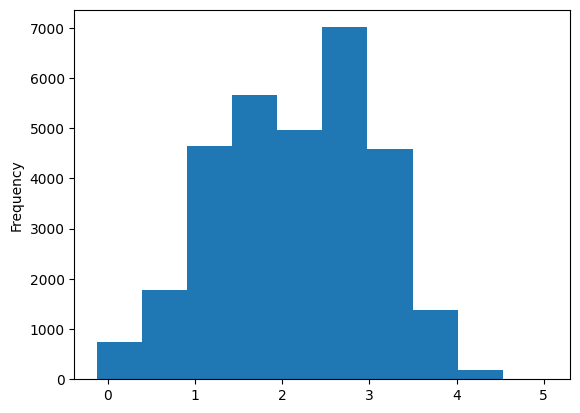

In [ ]:
df.q_sentiment.plot.hist()

In [ ]:
df.q_sentiment.describe()

,q_sentiment
count,30964.000000
mean,2.165400
std,0.881944
min,-0.124559
25%,1.473351
50%,2.217957
75%,2.877475
max,5.047039


**Text Classification with Out-of-the-Box Deep Learning Model**

In [ ]:
from transformers import pipeline

In [ ]:
# for GPU Runtime (need to connect to a GPU runtime, for example T4)
classifier = pipeline("text-classification", model="cardiffnlp/twitter-roberta-base-sentiment-latest", device = 0)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [ ]:
classifier("Covid cases are increasing fast!")

[{'label': 'negative', 'score': 0.7235766649246216}]

In [ ]:
classifier("Covid can be cured!")

[{'label': 'positive', 'score': 0.5347647666931152}]

In [ ]:
# Try the a random sample of 100 questions
N_sample = 1000
df_s = df.sample(n = N_sample, random_state = 1, ignore_index = True)
df_s = df_s.loc[:, ['id', 'question', 'q_sentiment']]

In [ ]:
df_s

,id,question,q_sentiment
0,1305,Recently the United States has decided to star...,1.874200
1,22628,Did you say that relevant Chinese parties will...,2.601768
2,14070,New satellite images released by a US think ta...,0.301538
3,23778,The DPRK has recently announced that it will n...,1.845428
4,14924,Is it true that the Chinese Embassy in the DPR...,0.311621
...,...,...,...
995,26644,You just said that if US House Speaker Nancy P...,0.522534
996,7388,"I have two questions. First, Inez Tenenbaum, C...",1.984328
997,1289,How will the dinner be held? Will it be anothe...,2.266936
998,28787,The UK’s former Prime Minister Liz Truss made ...,2.101740


In [ ]:
# # DON't DO THIS! Especially for large data
# text_sentiment_out_ls = sentiment_task(df_s.question.values.tolist())

In [ ]:
from tqdm.notebook import tqdm # Make progress bars

In [ ]:
text_sentiment_out_ls = []

for i in tqdm(range(df_s.shape[0])):
  out = classifier(df_s.loc[i, 'question'])[0]
  out['id'] = df_s.loc[i, 'id']
  out['q_sentiment'] = df_s.loc[i, 'q_sentiment']
  text_sentiment_out_ls.append(out)

  0%|          | 0/1000 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [ ]:
text_sentiment_out_df = pd.DataFrame(text_sentiment_out_ls)
text_sentiment_out_df

,label,score,id,q_sentiment
0,neutral,0.935035,1305,1.874200
1,neutral,0.931119,22628,2.601768
2,neutral,0.908999,14070,0.301538
3,neutral,0.697208,23778,1.845428
4,neutral,0.905886,14924,0.311621
...,...,...,...,...
995,neutral,0.823947,26644,0.522534
996,neutral,0.657514,7388,1.984328
997,neutral,0.953028,1289,2.266936
998,neutral,0.846358,28787,2.101740


Validate this result with manually labelled sentiment. It performs pretty well!

Text(0, 0.5, 'q_sentiment in the Dataset')

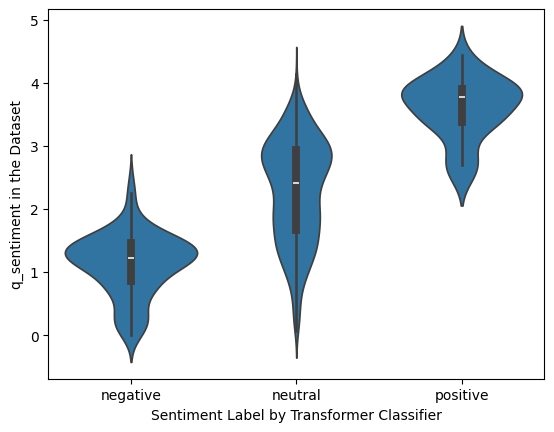

In [ ]:

sns.violinplot(x = "label", y = "q_sentiment",
               order = ["negative", "neutral", "positive"],
               data = text_sentiment_out_df)
plt.xlabel("Sentiment Label by Transformer Classifier")
plt.ylabel("q_sentiment in the Dataset")

#### Named entity extraction using LLM

##### Step 1: Get access token from huggingface

Please go register at huggingface and get a access token after verifying your email.

##### Step 2: Install packages

In [ ]:
!python -V  #Python 3.10.12

Python 3.10.12


In [ ]:
!nvcc --version # find the CUDA driver build above

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2023 NVIDIA Corporation
Built on Tue_Aug_15_22:02:13_PDT_2023
Cuda compilation tools, release 12.2, V12.2.140
Build cuda_12.2.r12.2/compiler.33191640_0


In [ ]:
# Install key libraries for LLM

#Install llama-cpp-python with CUBLAS, compatible to CUDA 12.2 which is the CUDA driver build above
!set LLAMA_CUBLAS=1
!set CMAKE_ARGS=-DLLAMA_CUBLAS=on
!set FORCE_CMAKE=1

#Install llama-cpp-python, cuda-enabled package
!python -m pip install llama-cpp-python==0.2.7 --prefer-binary --extra-index-url=https://jllllll.github.io/llama-cpp-python-cuBLAS-wheels/AVX2/cu122

#Install pytorch-related, cuda-enabled package
!pip install torch==2.3.0 torchvision==0.18.0 torchaudio==2.3.0 --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://pypi.org/simple, https://jllllll.github.io/llama-cpp-python-cuBLAS-wheels/AVX2/cu122
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.5 MB/s eta 0:00:00
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 781.0/781.0 MB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 90.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 93.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 87.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 50.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 103.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━

In [ ]:
#Working for GPU
%%writefile gpu_requirements.txt
annotated-types==0.7.0
anyio==4.4.0
certifi==2022.12.7
charset-normalizer==2.1.1
click==8.1.7
colorama==0.4.6
diskcache==5.6.3
dnspython==2.6.1
email_validator==2.1.1
exceptiongroup==1.2.1
filelock==3.13.1
fsspec==2024.6.0
h11==0.14.0
httpcore==1.0.5
httptools==0.6.1
httpx==0.27.0
huggingface-hub==0.23.3
idna==3.4
Jinja2==3.1.4
llama_cpp_python==0.2.7+cu122
markdown-it-py==3.0.0
MarkupSafe==2.1.5
mdurl==0.1.2
mpmath==1.3.0
networkx==3.2.1
numpy==1.26.4
orjson==3.10.3
packaging==24.0
pillow==10.2.0
pydantic==2.7.3
pydantic_core==2.18.4
Pygments==2.18.0
python-dotenv==1.0.1
python-multipart==0.0.9
PyYAML==6.0.1
requests==2.28.1
rich==13.7.1
shellingham==1.5.4
sniffio==1.3.1
starlette==0.37.2
sympy==1.12
torch==2.3.0+cu121
torchaudio==2.3.0+cu121
torchvision==0.18.0+cu121
tqdm==4.66.4
typer==0.12.3
typing_extensions==4.12.1
ujson==5.10.0
watchfiles==0.22.0

Writing gpu_requirements.txt


In [ ]:
!pip install -r gpu_requirements.txt #it's normal to see incompatiblity errors; the most important packages have been installed correctly

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.3/155.3 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.7/307.7 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.9/176.9 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.4/341.4 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.7/401.7 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

##### Step 3: Download almost any huggingface LLM

Use the "hf_hub_download" function to download models on huggingface using the access token from Step 1. In this case, I want to download a small model of the "llava-1.6-mistral-7b-gguf" model from "cjpais"'s huggingface repository.

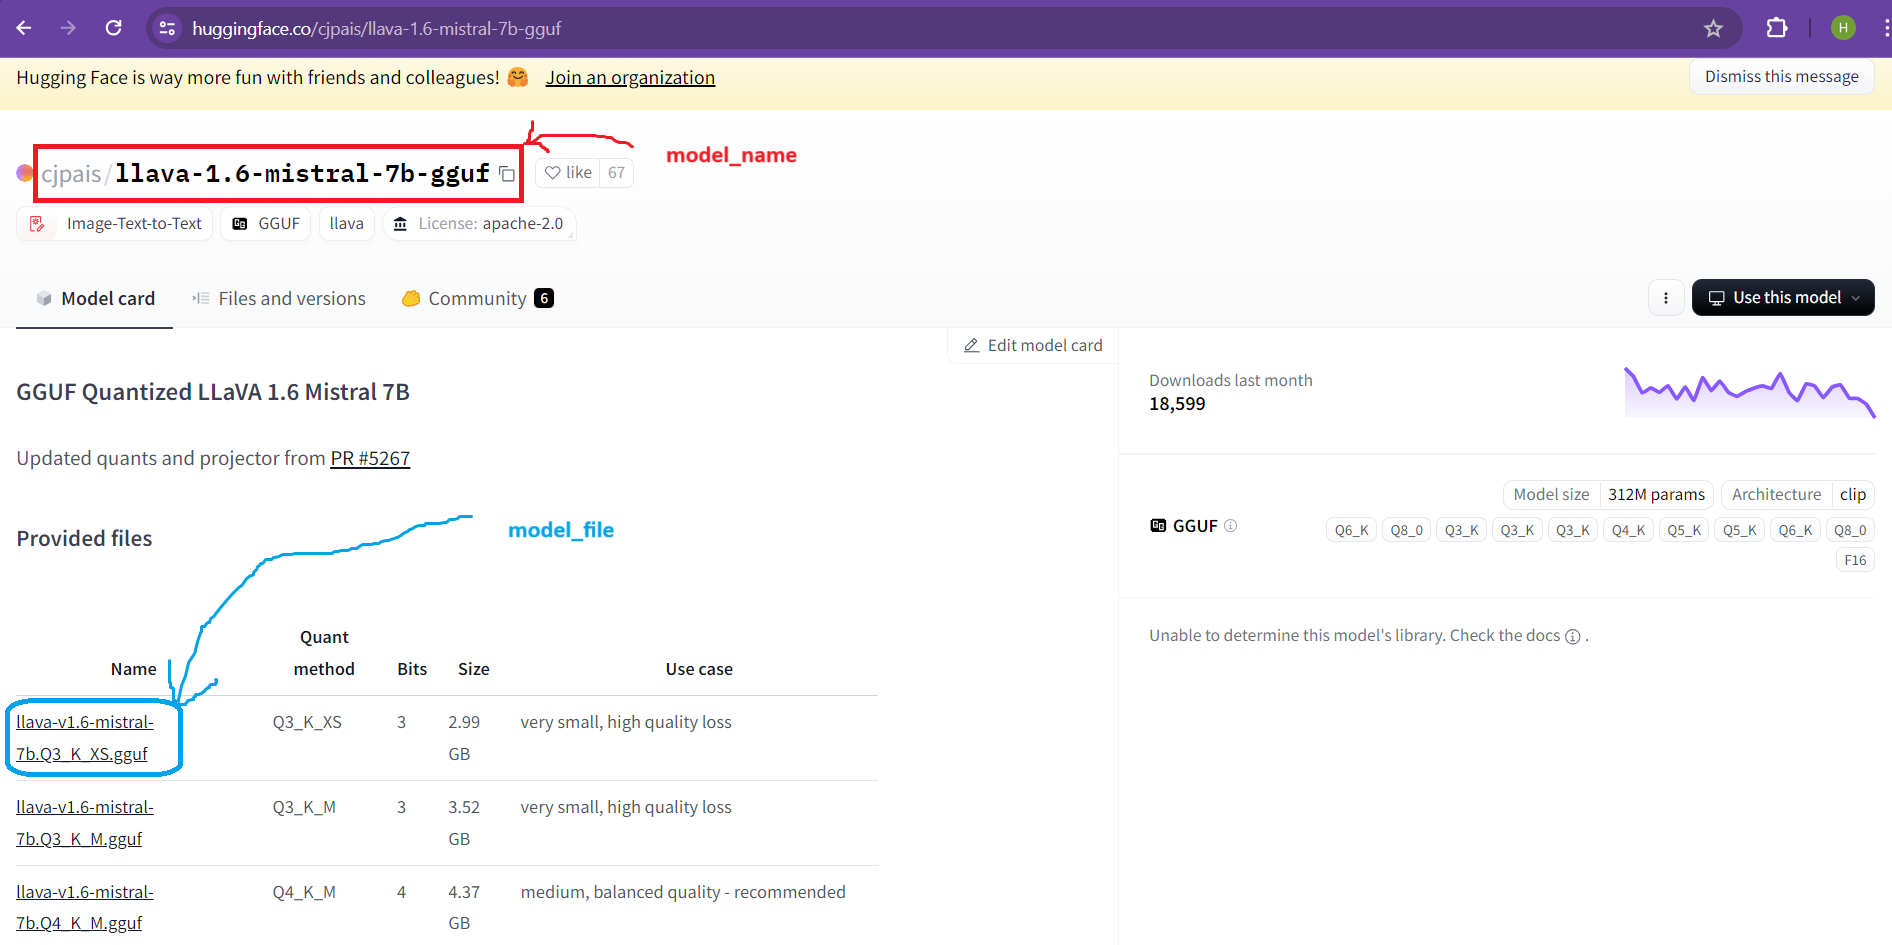

In [ ]:
import torch
import huggingface_hub

In [ ]:
import os
from huggingface_hub import hf_hub_download

# Function to read the token from a file
def read_token(file_path):
    try:
        with open(file_path, 'r') as file:
            return file.readline().strip()
    except FileNotFoundError:
        raise ValueError(f"Token file not found: {file_path}")

# Define the model name and file
model_name = "cjpais/llava-1.6-mistral-7b-gguf"
model_file = "llava-v1.6-mistral-7b.Q3_K_XS.gguf"


# Download the model from Hugging Face Hub
model_path = hf_hub_download(
    model_name,
    filename=model_file,
    local_dir='models/',  # Download the model to the "models" folder
    token=" "  #Replace this token from huggingface with your own token (Setting -> Access Toekns -> New token -> Generate Token)
)

print("My model path:", model_path)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


llava-v1.6-mistral-7b.Q3_K_XS.gguf:   0%|          | 0.00/2.99G [00:00<?, ?B/s]

My model path: models/llava-v1.6-mistral-7b.Q3_K_XS.gguf


In [ ]:
from llama_cpp import Llama

# model_path is location of to the GGUF model that you've download from HuggingFace on Colab
model_path = "/content/models/llava-v1.6-mistral-7b.Q3_K_XS.gguf"

#load the LLM
llm = Llama(model_path=model_path,
            n_gpu_layers=-1) #load model while enabling GPU

AVX = 1 | AVX2 = 1 | AVX512 = 0 | AVX512_VBMI = 0 | AVX512_VNNI = 0 | FMA = 1 | NEON = 0 | ARM_FMA = 0 | F16C = 1 | FP16_VA = 0 | WASM_SIMD = 0 | BLAS = 1 | SSE3 = 1 | SSSE3 = 1 | VSX = 0 | 


Note that BLAS = 1 means GPU is enabled:
*   AVX = 1 | AVX2 = 1 | AVX512 = 0 | AVX512_VBMI = 0 | AVX512_VNNI = 0 | FMA = 1 | NEON = 0 | ARM_FMA = 0 | F16C = 1 | FP16_VA = 0 | WASM_SIMD = 0 | BLAS = 1 | SSE3 = 1 | SSSE3 = 1 | VSX = 0 |



##### Step 4: Ask the LLM a question

In [ ]:
user_question = "What is the earliest civilization in the world?" # @param {type:"string"}

In [ ]:
import time

# Prompt creation
system_message = "You are a helpful assistant"
user_message = "Q: "+ user_question + " A: "

# Start the timer
start_time = time.time()

prompt = f"""<s>[INST] <<SYS>>
{system_message}
<</SYS>>
{user_message} [/INST]"""

# Run the model
output = llm(
  prompt, # Prompt
  max_tokens=2000, # Generate up to 2,000 tokens
  stop=["Q:", "\n"], # Stop generating just before the model would generate a new question
  echo=False # Echo the prompt back in the output
)

# Stop the timer
end_time = time.time()

# Get model response
print(output["choices"][0]["text"])

# Calculate runtime
runtime = end_time - start_time
print("response run time is: ", runtime)

Llama.generate: prefix-match hit


 The answer to this question can be traced back through various civilizations. In general, the concept of "civilization" typically refers to a complex society with organized systems, such as government and economy. With that said, however, it's important to note that the exact definition and criteria for what constitutes a "civilization" may vary depending on the perspective or historical context.
response run time is:  2.8058412075042725


##### Use Large Language Model to analyze the MoFA data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

Mounted at /content/drive


In [ ]:
# ATTENTION: Change the path to your project folder
PROJECT_FOLDER = '/content/drive/MyDrive/POLI3148/Week10/text_analysis'

In [ ]:
# Load the raw data frame
df = pd.read_excel(os.path.join(PROJECT_FOLDER, "data_raw/Copy of CMFA_PressCon_v4.xlsx"))

In [ ]:
# Examine the df
df

,id_orig,id_split,id,link,spokesperson,day,month,year,date,question,...,q_loc,q_per,q_org,q_misc,a_loc,a_per,a_org,a_misc,a_sentiment,q_sentiment
0,1,1,1,http://web.archive.org/web/20030907084940/http...,Zhang Qiyue,15,October,2002,2002-10-15 00:00:00,How many Hong Kong and Taiwan people were inju...,...,Taiwan; Mainland; Indonesia; Hong Kong; Bali I...,-,-,Chinese,Taiwan; Mainland; Macao; Indonesia; Hong Kong;...,-,Government,Indonesian; Chinese,2.354945,0.939969
1,2,2,2,http://web.archive.org/web/20030907084940/http...,Zhang Qiyue,15,October,2002,2002-10-15 00:00:00,"Today, five Japanese who were kidnapped by the...",...,North Korea; China,-,-,-,Japan; DPRK; China,-,-,Japan-DPRK,5.112201,2.474082
2,3,3,3,http://web.archive.org/web/20030907084940/http...,Zhang Qiyue,15,October,2002,2002-10-15 00:00:00,Recently Nepal formed an interim government. H...,...,Nepal,-,-,-,Nepal; China,-,Nepali Interim Government,Nepali; Five Principles of Peaceful Coexistenc...,4.926227,3.039821
3,4,4,4,http://web.archive.org/web/20030907084940/http...,Zhang Qiyue,15,October,2002,2002-10-15 00:00:00,Pakistan held the general election on 10 Octob...,...,-,-,-,-,Pakistan; China,-,-,China-Pakistan,5.282908,2.699500
4,5,5,5,http://web.archive.org/web/20030907084940/http...,Zhang Qiyue,15,October,2002,2002-10-15 00:00:00,Is China concerned about the rise of the funda...,...,US; Pakistan; China,-,-,-,Pakistan,-,-,Pakistani,5.174895,2.123604
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30959,29093,29093,30960,https://www.fmprc.gov.cn/eng/xwfw_665399/s2510...,Mao Ning,29,December,2023,2023-12-29 00:00:00,"In an interview with RIA news agency, Russian ...",...,Russia; Global South; China,Volodymyr Zelenskyy; Sergey Lavrov,RIA,Western; Ukrainian; Russian,Ukraine; China,-,-,Chinese,4.447462,2.524199
30960,29094,29094,30961,https://www.fmprc.gov.cn/eng/xwfw_665399/s2510...,Mao Ning,29,December,2023,2023-12-29 00:00:00,A spokesperson of one of the local armed group...,...,Myanmar; China,-,NHK,Chinese,Myanmar; China-Myanmar; China,-,-,-,4.202277,1.660094
30961,29095,29095,30962,https://www.fmprc.gov.cn/eng/xwfw_665399/s2510...,Mao Ning,29,December,2023,2023-12-29 00:00:00,It’s reported that the spokesperson of the Arm...,...,Ren’ai Jiao; Philippines,Aguilar,Armed Forces of the Philippines,Philippino,South China Sea; Ren’ai Jiao; Philippines; Nan...,Ren’ai Jiao,Nansha Qundao; Crown Hotel; Armed Forces of th...,UN Charter; Ren’ai Jiao; DOC; Declaration on t...,1.731000,2.697861
30962,29096,29096,30963,https://www.fmprc.gov.cn/eng/xwfw_665399/s2510...,Mao Ning,29,December,2023,2023-12-29 00:00:00,It’s been learned that firing broke out in fro...,...,Myanmar; Laukkaing Township; Laukkaing; Dong C...,-,Crown Hotel,Chinese,Myanmar; Kokang; China,-,Foreign Ministry,Chinese,0.507228,1.371034


In [ ]:
# Select a document
df.loc[0, "question"]

'How many Hong Kong and Taiwan people were injured in the blasts in the Bali Island, Indonesia? Are there any Mainland citizens injured? What has the Chinese Embassy in Indonesia done in this regard?'

In [ ]:
# Ask a very simple example:

user_question = f"""
What countries does the following text mention?

{df.loc[0, "question"]}
"""

print(user_question)


What countries does the following text mention?

How many Hong Kong and Taiwan people were injured in the blasts in the Bali Island, Indonesia? Are there any Mainland citizens injured? What has the Chinese Embassy in Indonesia done in this regard?



In [ ]:
import time

# Prompt creation
system_message = "You are a helpful research assistant. "
user_message = "Q: "+ user_question + " A: "

# Start the timer
start_time = time.time()

prompt = f"""<s>[INST] <<SYS>>
{system_message}
<</SYS>>
{user_message} [/INST]"""

# Run the model
output = llm(
  prompt, # Prompt
  max_tokens=2000, # Generate up to 2,000 tokens
  stop=["Q:", "\n"], # Stop generating just before the model would generate a new question
  # echo=True # Echo the prompt back in the output
)

# Stop the timer
end_time = time.time()

# Get model response
print(output["choices"][0]["text"])

# Calculate runtime
runtime = end_time - start_time
print("response run time is: ", runtime)

Llama.generate: prefix-match hit


 The given text mentions four countries, which are China, Hong Kong, Taiwan, and Indonesia. The text reports that a total of eight people were injured in the blasts in Bali Island, Indonesia - four Hong Kong citizens, three Taiwanese citizens, and one Mainland Chinese citizen. The Chinese Embassy in Indonesia has not yet provided any information regarding their assistance to the injured. 
response run time is:  3.19970440864563


In [ ]:
def extract_country(text):
  # Prompt creation
  system_message = "You are a helpful research assistant. "
  user_question = "What countries does the following text mention?"
  user_message = "Q: "+ user_question + text + " A: "

  # Start the timer
  start_time = time.time()

  prompt = f"""<s>[INST] <<SYS>>
  {system_message}
  <</SYS>>
  {user_message} [/INST]"""

  # Run the model
  output = llm(
    prompt, # Prompt
    max_tokens=2000, # Generate up to 2,000 tokens
    stop=["Q:", "\n"], # Stop generating just before the model would generate a new question
    # echo=True # Echo the prompt back in the output
  )

  return output["choices"][0]["text"]


In [ ]:
extract_country(df.loc[0, "answer"])

Llama.generate: prefix-match hit


' This text mentions China, Indonesia, and unspecified "other countries." It says that China is opposed to terrorism of all forms, and strongly condemns the violent activity in Indonesia and other countries. The text then expresses deep sympathy for victims of Indonesia and other countries and their relatives.'

In [ ]:
# Extract countries for the first 20 questions
texts = df.loc[:20, "question"]

In [ ]:
result = []

for text in texts:
  r = extract_country(text)
  restult.append(r)
  print(text)

Llama.generate: prefix-match hit


How many Hong Kong and Taiwan people were injured in the blasts in the Bali Island, Indonesia? Are there any Mainland citizens injured? What has the Chinese Embassy in Indonesia done in this regard?


Llama.generate: prefix-match hit


Today, five Japanese who were kidnapped by the North Korea returned home and what is China's comment?


Llama.generate: prefix-match hit


...

Are there any latest developments in the US boy custody case in Zhengzhou? Has the US contacted China in this regard?


Llama.generate: prefix-match hit


Did the North Korean delegation that is on a visit in China at present give hint to China that North Korea has a program for nuclear weapons development? Would you please tell us something about the meeting between the delegation and Chinese leaders?


Llama.generate: prefix-match hit


Iraqi President Saddam has once again won the general election. What is China's comment?


In [ ]:
result

[" I'm sorry, but I cannot provide you with specific information about the countries mentioned in the text.",
 ' In my previous message, I mentioned that one of the main points in my research project is to focus on Chinese culture. Specifically, I am interested in exploring how Chinese culture has evolved over time and how it continues to shape the lives of people around the world.',
 ' <</sys>>',
 ' The text mentions Pakistan. ',
 ' The text mentions China and Pakistan, but not the United States or any other specific country.',
 ' 根据提供的文本，以下文本没有提及国家名称：',
 ' The mentioned text mentions the United States.',
 ' The text mentions Iraq, Australia, and New Zealand.',
 ' There seems to be a misunderstanding as I am a language model and do not have access to current events or specific countries as they change over time. Additionally, there is no text provided for me to analyze or comment on. ',
 ' The text mentions the United States and China. ',
 " The image you've provided is not in English

It can be seen that the model does not perform exceptionally well on our assigned tasks. That is because the model is relatively small. A larger model can work better, but also comsume a lot more computational resources.